# A Rule-Based Method for Classifying Housing Archetypes | Compare

This notebook compares the results of the other two notebooks: **Verisk** and **EPC**. Note that the Excel data is manually worked. 

Both **Verisk** and **EPC** notebooks implement the same rule-based classification scheme for turning raw property records into housing "archetype" codes (e.g. **B-DT, DT-R, SD-V, TR-M, TG-E**), but they apply it to two different source datasets — one built from EPC (Energy Performance Certificate) data, the other from Verisk property data. The overall structure, logic, and even variable names are nearly identical, suggesting one notebook was adapted from the other.

EPC data provides an explicit `property_type` / `built_form` and `total_floor_area`, so classification is more direct. 

Verisk data lacks an explicit bungalow category and has complicated `floor-count `data, so the notebook does more upfront cleaning (dropping/renaming categories, fixing malformed values) and infers "bungalow" from floor count rather than a labelled type. Verisk also has a generic "Terrace" category that EPC's built_form values don't include, requiring an extra classification branch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print(f"Pandas version: {pd.__version__}") # Print pandas version to confirm installation

Pandas version: 3.0.3


In [2]:
# import (pre-processed) data via Excel

Result = pd.read_excel('SY_Archetypes_Quantification_Results.xlsx', sheet_name='stocksize')

In [3]:
df_result= pd.DataFrame(Result)

In [4]:
df_result.head(15)

,Archetype,Verisk,EPC
0,*DT-V,35529,8339.500000
1,DT-L,30448,3697.666667
2,T-GE,4859,30.000000
3,*SD-V,45367,4926.000000
4,T-GM,4894,385.000000
5,*T-VE,21068,4819.000000
6,B-DT,17001,21349.000000
7,*T-VM,30876,9060.000000
8,DT-R,27446,42502.000000
9,SD-S,109739,23119.000000


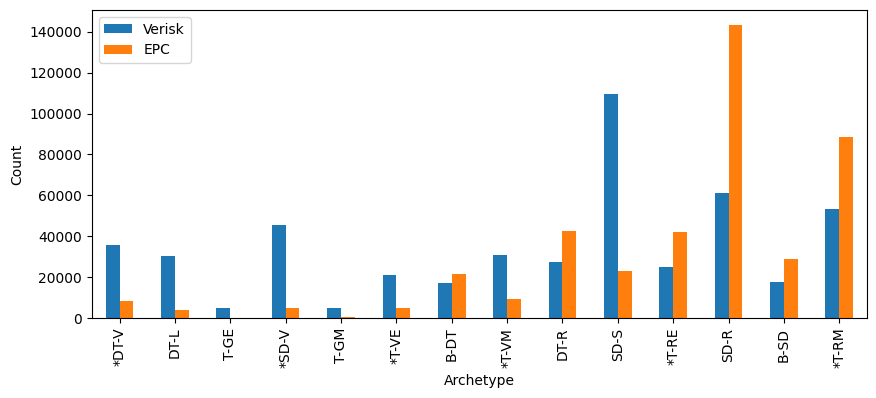

In [5]:
# Plotting side-by-side
ax = df_result.plot(x='Archetype', y=['Verisk', 'EPC'], kind='bar', figsize=(10, 4))

# Place legend inside the plot area at the top left
plt.legend(loc='upper left')

plt.ylabel("Count")
plt.show()